In [97]:
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict


# Функция для извлечения координат из файла
def coordinates_extraction(file_path, is_clinics=True):
    # Регулярное выражение для поиска координат и названий
    if is_clinics:
        pattern = r"([^(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)"
    else:
        pattern = r"([^\(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)"
    
    # Список для хранения координат и названий
    coordinates = []
    
    # Чтение файла
    with open(file_path, 'r', encoding='utf-8') as file:
        # Обрабатываем строки из файла
        for line in file:
            matches = re.findall(pattern, line)
            for match in matches:
                name = match[0].strip()
                x, y = round(float(match[1]), 6), round(float(match[2]), 6)
                coordinates.append([name, x, y])
    
    return coordinates


# Функция нормализации координат в диапазон [0,1]
def normalize_coordinates(data):
    coords = np.array([[c[1], c[2]] for c in data])
    min_vals = coords.min(axis=0)
    max_vals = coords.max(axis=0)
    normalized = (coords - min_vals) / (max_vals - min_vals)
    return [[data[i][0], *normalized[i]] for i in range(len(data))]


# Функция для вычисления Евклидова расстояния
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

# Функция для обучения нейронной сети Кохонена
def kohonen_network(clinics, weights, learning_rate=0.3, num_epochs=10):

    weights = np.array([[c[1], c[2]] for c in weights])

    # Визуализация начальных весов (до обучения)    
    plot_clustering(clinics, weights, epoch=0)
    
    # Обучение сети
    for epoch in range(num_epochs):
        learning_rate_epoch = learning_rate * (1 - epoch / num_epochs)  # Уменьшение скорости обучения
    
        for clinic in clinics:
            
            input_vector = np.array(clinic[1:]) 
            # Вычисляем расстояние от поликлиники до каждого округа
            distances = np.array([euclidean_distance(input_vector, w) for w in weights])
            
            # Нейрон (округ) с минимальным расстоянием побеждает
            winning_neuron = np.argmin(distances)
            # Обновление весов победившего нейрона (округа)
            weights[winning_neuron] += learning_rate_epoch * (input_vector - weights[winning_neuron])
        
        
        # Визуализация после каждой эпохи
        plot_clustering(clinics, weights, epoch + 1)
    
    return weights


# Функция визуализации процесса обучения
def plot_clustering(clinics, weights, epoch):
    clinics_coords = np.array([[c[1], c[2]] for c in clinics])
    cluster_coords = np.array(weights)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(clinics_coords[:, 0], clinics_coords[:, 1], c='blue', label='Поликлиники', marker='o')
    plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1], c='red', label='Кластеры (центры)', marker='x')

    for i, clinic in enumerate(clinics):
        winner = np.argmin([euclidean_distance(clinic[1:], w) for w in weights])
        plt.plot([clinic[1], weights[winner, 0]], [clinic[2], weights[winner, 1]], 'gray', linestyle='--')
    
    if epoch == 0:
        plt.title(f"Распределение поликлиник по кластерам (до обучения)")  
    else:
        plt.title(f"Распределение поликлиник по кластерам (Эпоха {epoch})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Функция для кластеризации (определяем победивший нейрон для каждой клиники)
def kohonen_clustering(clinics, weights):
    assignments = []
    for clinic in clinics:
        # Вычисление расстояний между входным вектором и весами нейронов
        distances = np.array([euclidean_distance(clinic[1:], w) for w in weights])  # Используем только координаты (x, y)
        
        # Нейрон с минимальным расстоянием побеждает
        winning_neuron = np.argmin(distances)
        assignments.append(winning_neuron)
    
    return assignments



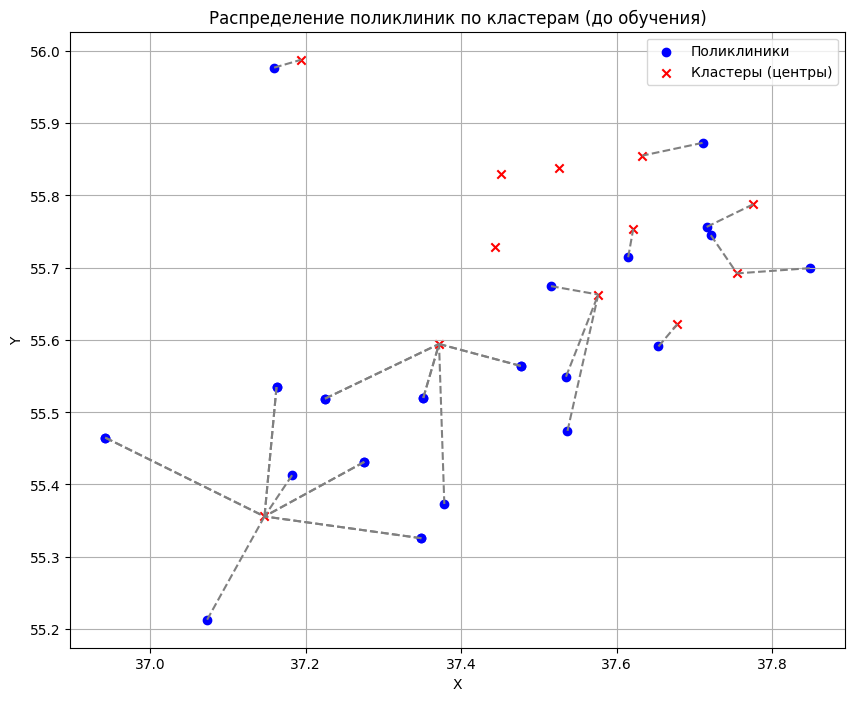

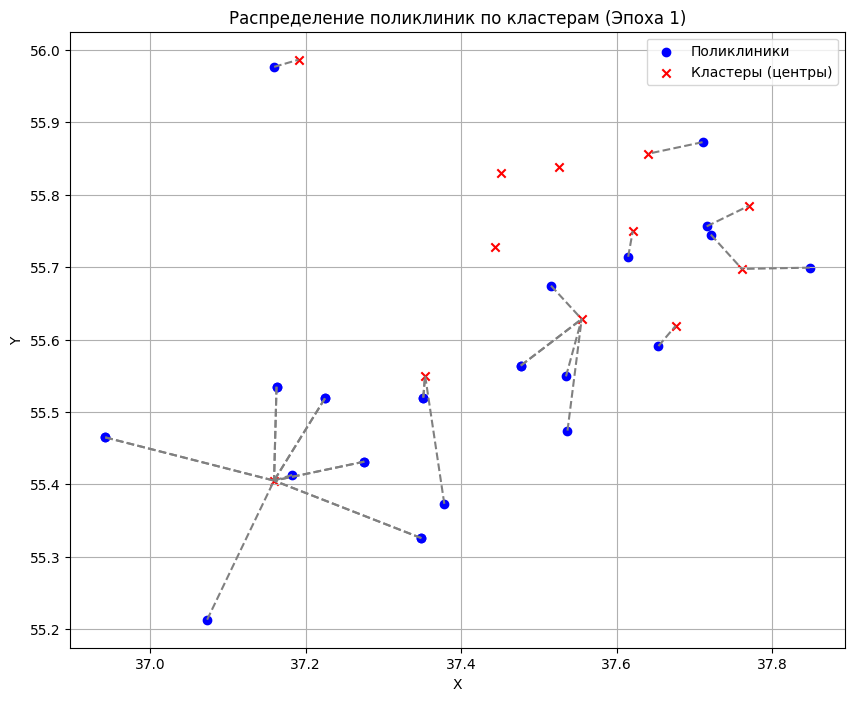

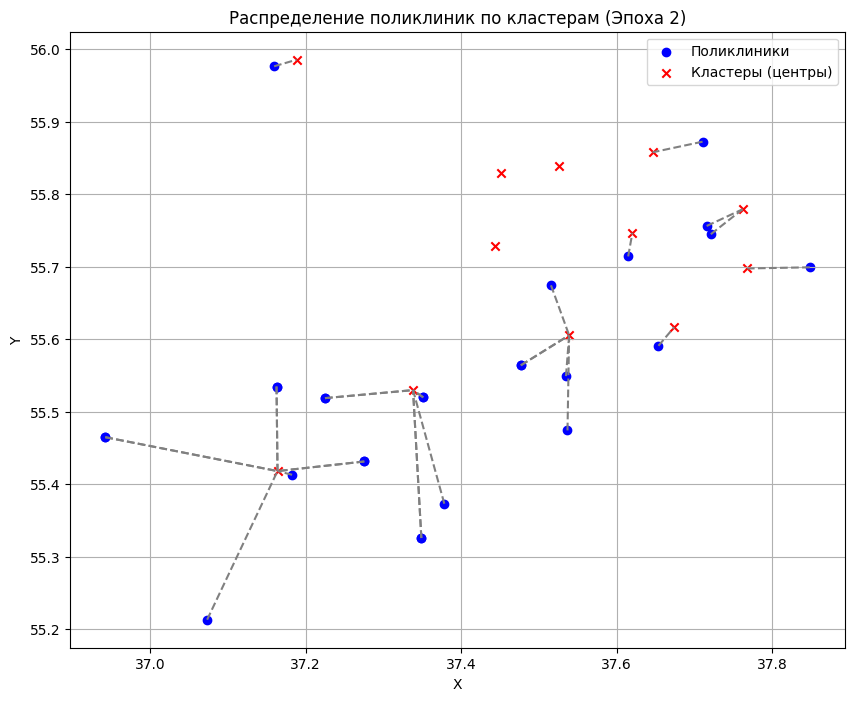

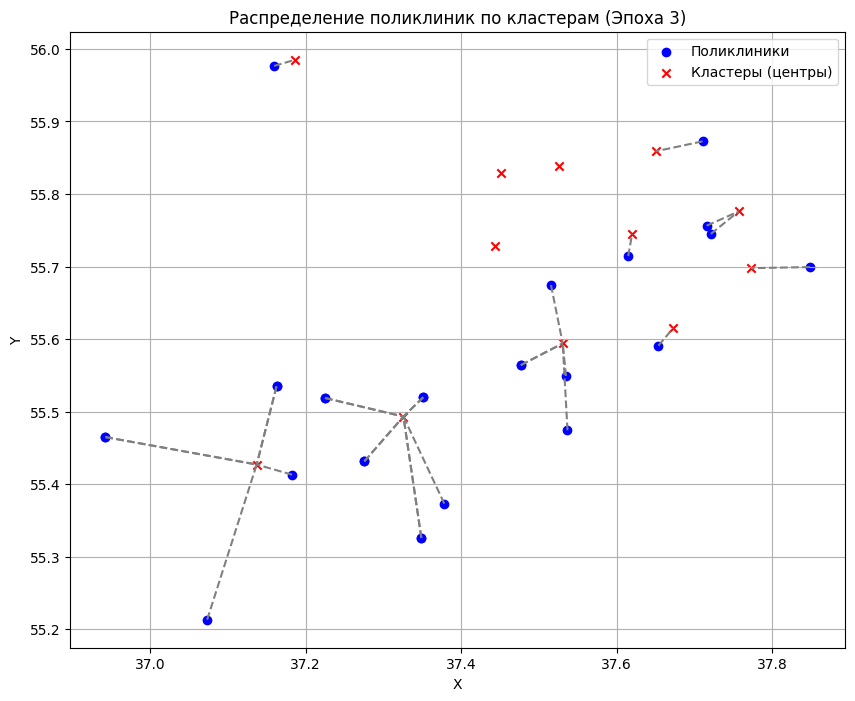

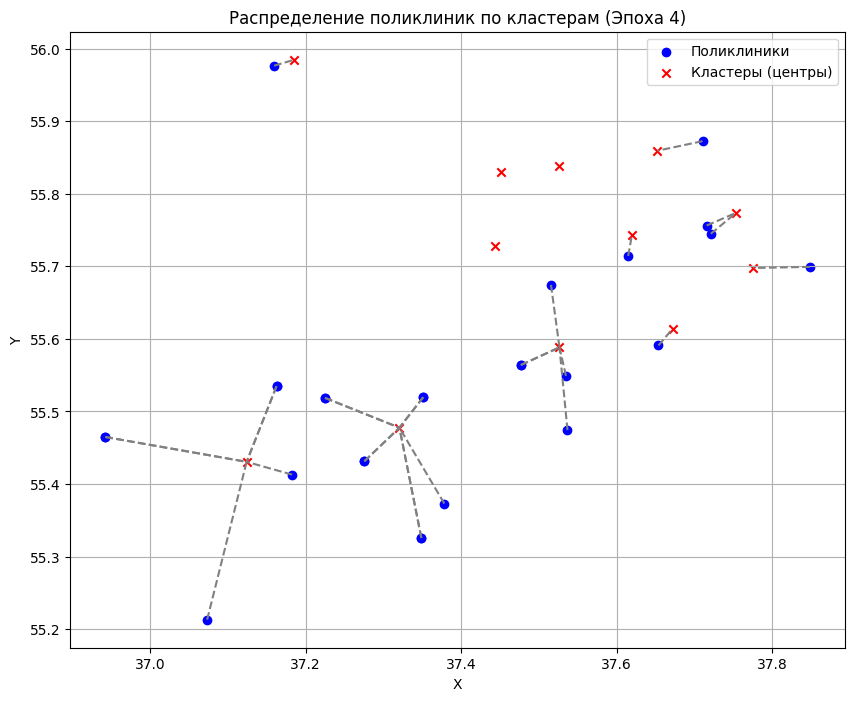

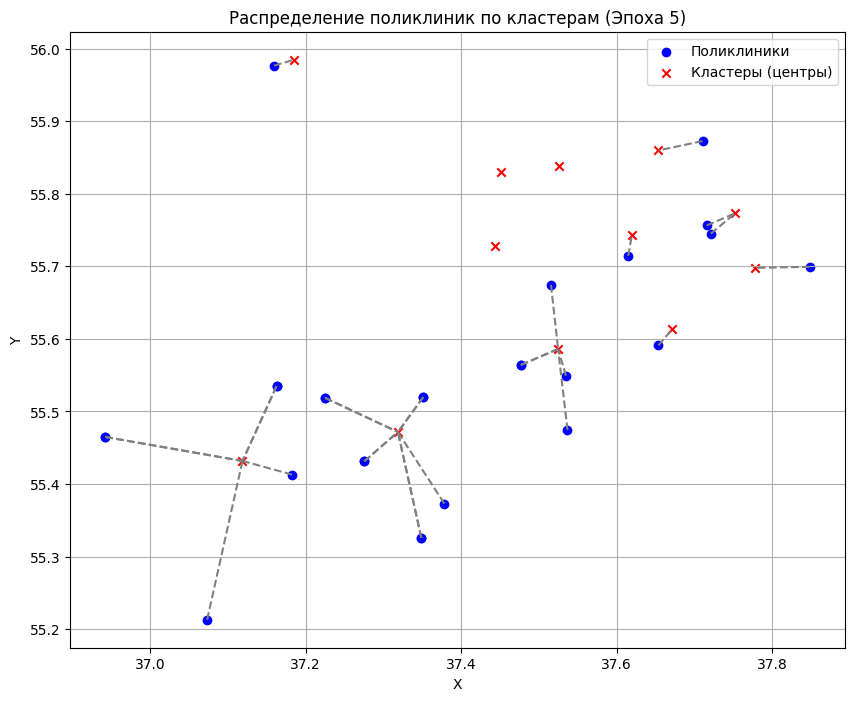


Итоговые веса:
Центральный АО: [37.619438 55.743072]
Северный АО: [37.525774 55.83839 ]
Северо-Восточный АО: [37.65338  55.859614]
Восточный АО: [37.752283 55.773026]
Юго-Восточный АО: [37.777194 55.697831]
Южный АО: [37.671514 55.6137  ]
Юго-Западный АО: [37.524524 55.58601 ]
Западный АО: [37.443533 55.728003]
Северо-Западный АО: [37.451555 55.82937 ]
Зеленоградский АО: [37.184897 55.984643]
Новомосковский АО: [37.318571 55.471615]
Троицкий АО: [37.118707 55.43171 ]

Округ                          Поликлиника
------------------------------------------------------------
Центральный АО                 ГБУЗ ГКБ № 1 им.Н.И. Пирогова ДЗМ филиал ЧЛГ для ВВ. Стоматологическое отделение
____________________________________________________________
Северный АО                    Нет назначенных клиник
____________________________________________________________
Северо-Восточный АО            ГАУЗ СП № 32 ДЗМ. Стоматологическое отделение
_________________________________________________________

In [98]:
# Открываем файл с данными
clinics_path = "clinics.txt"  # Путь к файлу с координатами клиник
clusters_path = "clusters.txt" # Путь к файлу с координатами кластеров
clinics = coordinates_extraction(clinics_path, is_clinics=True) 
clusters = coordinates_extraction(clusters_path, is_clinics=False)

# Нормализация координат
# clinics = normalize_coordinates(clinics)
# clusters = normalize_coordinates(clusters)

# Преобразование данных
clinics_coords = np.array([[c[1], c[2]] for c in clinics])
cluster_coords = np.array([[c[1], c[2]] for c in clusters])
cluster_names = [c[0] for c in clusters]


eta = 0.1
epochs = 5
# Кластеризация с обучением нейронной сети Кохонена
weights = kohonen_network(clinics, clusters, eta, epochs)
# Получаем присвоенные кластеры для каждой клиники  
assignments = kohonen_clustering(clinics, weights)

print("\nИтоговые веса:")
for i, weight in enumerate(weights):
    # Округляем каждый компонент веса
    rounded_weight = np.round(weight, 6)
    print(f"{cluster_names[i]}: {rounded_weight}")

# Группируем результаты кластеризации: ключ – название округа, значение – список поликлиник
results = defaultdict(set)
for clinic, assignment in zip(clinics, assignments):
    district_name = clusters[assignment][0]
    results[district_name].add(clinic[0])

# Вывод таблицы для конечных весов (центров кластеров)
print("\n{:<30} {:<}".format("Округ", "Поликлиника"))
print("-" * 60)
for district in cluster_names:
    clinics_in_district = sorted(results.get(district, []))  # Сортируем поликлиники по имени для упорядоченности
    if clinics_in_district:
        # Выводим первую строку с округом и первой поликлиникой
        print("{:<30} {:<}".format(district, clinics_in_district[0]))
        # Если поликлиник больше одной, выводим остальные с отступом в столбце округов
        for clinic_name in clinics_in_district[1:]:
            print("{:<30} {:<}".format("", clinic_name))
    else:
        print("{:<30} {:<}".format(district, "Нет назначенных клиник"))
    
    # Разделитель между округами
    print("_" * 60)


